In [1]:
## Load all necessary libraries

import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cf
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas
from matplotlib.ticker import AutoMinorLocator
import os
import scipy
from netCDF4 import Dataset as netcdf_dataset
import matplotlib
matplotlib.matplotlib_fname()
print(plt.style.available)
matplotlib.rcParams['font.sans-serif'] = 'Arial'

Missing colon in file 'matplotlibrc', line 15 ('is set)')
Missing colon in file 'matplotlibrc', line 23 ('file.')
Missing colon in file 'matplotlibrc', line 26 ('are')
Missing colon in file 'matplotlibrc', line 31 ('codebase).')
Missing colon in file 'matplotlibrc', line 33 ("'#'s")
Missing colon in file 'matplotlibrc', line 80 ('***************************************************************************')
Missing colon in file 'matplotlibrc', line 82 ('*')
Missing colon in file 'matplotlibrc', line 84 ('***************************************************************************')
Missing colon in file 'matplotlibrc', line 93 ('to')
Missing colon in file 'matplotlibrc', line 120 ('Europe/Paris')
Missing colon in file 'matplotlibrc', line 124 ('***************************************************************************')
Missing colon in file 'matplotlibrc', line 126 ('*')
Missing colon in file 'matplotlibrc', line 128 ('******************************************************************

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
## Load the climate model data, pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP6_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/baseline/'
CMIP6_directory2 = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/endcentury/'

CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_allmonths/change/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_allmonths/baseline/'

# Load historic variability
CMIP6_p33_directory = '/Users/ak0920/Data/ESMValTool/output/past_var/pc33/'
CMIP6_p67_directory = '/Users/ak0920/Data/ESMValTool/output/past_var/pc67/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P_CMIP6 = np.empty(shape=(360,44,40,44,2)) # month x lat x long x model x time period
P_CMIP6_pcs = np.empty(shape=(12,44,40,44,2)) # month x lat x long x model x percentile
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_directory):
    dirnames.sort()
    names = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filename_alt = filename[0:-12]+'1985-2014.nc'
            filename_alt2 = filename[0:-12]+'1900-2014.nc'
                               
            filenamelong = CMIP6_base_directory+filename_alt
            filenamelong1 = CMIP6_p33_directory+filename_alt2
            filenamelong2 = CMIP6_p67_directory+filename_alt2
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P_CMIP6[:,:,:,count,0] = P1[:,53:53+44,11:11+40] # This region covers Zambia
            
            thismod_ds = xr.open_dataset(filenamelong1)
            P1 = thismod_ds["pr"] * 86400
            thismod_ds = xr.open_dataset(filenamelong2)
            P2 = thismod_ds["pr"] * 86400
            P_CMIP6_pcs[:,:,:,count,0] = P1[:,53:53+44,11:11+40] # This region covers Zambia
            P_CMIP6_pcs[:,:,:,count,1] = P2[:,53:53+44,11:11+40] # This region covers Zambia
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_directory2):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P_CMIP6[:,:,:,count,1] = P1[:,53:53+44,11:11+40] # This region covers Zambia
            count = count + 1


In [3]:
## Generate date information

import datetime
from datetime import date
startt = date.fromisoformat('1980-01-01')
endt2 = date.fromisoformat('1981-01-01')

lats = thismod_ds.variables['lat'][53:53+44]
lons = thismod_ds.variables['lon'][11:11+40]
dates = pd.date_range(startt,endt2-datetime.timedelta(days=1),freq='m')

#dates

In [4]:
## Code for trend analysis
# P_all = P_CMIP6[:,:,:,:,0] + P_CMIP6[:,:,:,:,1]
P_all = P_CMIP6[:,:,:,:,1]
P_all_pcs = P_CMIP6_pcs

# Blank output arrays
TrendsJJA = np.empty([30,44,40,44])
TrendsSON = np.empty([30,44,40,44])
TrendsDJF = np.empty([30,44,40,44])
TrendsMAM = np.empty([30,44,40,44])

for y in range(0,30):
    # For MAM
    month_pattern = [2,3,4]
    month_pattern2a = 2+y*12
    month_pattern2b = 4+y*12
    
    P = np.mean(P_all[month_pattern2a:month_pattern2b,:,:,:],axis=0)
    P33 = np.mean(P_all_pcs[month_pattern,:,:,:,0],axis=0)
    P67 = np.mean(P_all_pcs[month_pattern,:,:,:,1],axis=0)
    
    # Check each grid cell and model
    for i in range(0,44):
        for j in range(0,40):
            for k in range(0,44):
                # Steady large increase
                if P[i,j,k] >= P33[i,j,k] and P[i,j,k] <= P67[i,j,k]:
                    TrendsMAM[y,i,j,k] = 0
        
                # Peak increase
                if P[i,j,k] < P33[i,j,k]:
                    TrendsMAM[y,i,j,k] = -1
                
                # Dip increase
                if P[i,j,k] > P67[i,j,k]:
                    TrendsMAM[y,i,j,k] = 1
                
    # For JJA
    month_pattern = [5,6,7]
    month_pattern2a = 5+y*12
    month_pattern2b = 7+y*12
    
    P = np.mean(P_all[month_pattern2a:month_pattern2b,:,:,:],axis=0)
    P33 = np.mean(P_all_pcs[month_pattern,:,:,:,0],axis=0)
    P67 = np.mean(P_all_pcs[month_pattern,:,:,:,1],axis=0)

    # Check each grid cell and model
    for i in range(0,44):
        for j in range(0,40):
            for k in range(0,44):
                # Steady large increase
                if P[i,j,k] >= P33[i,j,k] and P[i,j,k] <= P67[i,j,k]:
                    TrendsJJA[y,i,j,k] = 0
    
                # Peak increase
                if P[i,j,k] < P33[i,j,k]:
                    TrendsJJA[y,i,j,k] = -1
                
                # Dip increase
                if P[i,j,k] > P67[i,j,k]:
                    TrendsJJA[y,i,j,k] = 1
                
    # For SON
    month_pattern = [8,9,10]
    month_pattern2a = 8+y*12
    month_pattern2b = 10+y*12
    
    P = np.mean(P_all[month_pattern2a:month_pattern2b,:,:,:],axis=0)
    P33 = np.mean(P_all_pcs[month_pattern,:,:,:,0],axis=0)
    P67 = np.mean(P_all_pcs[month_pattern,:,:,:,1],axis=0)


    # Check each grid cell and model
    for i in range(0,44):
        for j in range(0,40):
            for k in range(0,44):
                # Steady large increase
                if P[i,j,k] >= P33[i,j,k] and P[i,j,k] <= P67[i,j,k]:
                    TrendsSON[y,i,j,k] = 0
    
                # Peak increase
                if P[i,j,k] < P33[i,j,k]:
                    TrendsSON[y,i,j,k] = -1
                
                # Dip increase
                if P[i,j,k] > P67[i,j,k]:
                    TrendsSON[y,i,j,k] = 1

    # For DJF
    month_pattern = [0,1,11]
    if y == 0:
        month_pattern2 = [0,1]
        P = np.mean(P_all[month_pattern2,:,:,:],axis=0)
    else:
        month_pattern2a = -1+y*12
        month_pattern2b = 1+y*12
    
        P = np.mean(P_all[month_pattern2a:month_pattern2b,:,:,:],axis=0)
    
    P33 = np.mean(P_all_pcs[month_pattern,:,:,:,0],axis=0)
    P67 = np.mean(P_all_pcs[month_pattern,:,:,:,1],axis=0)

    # Check each grid cell and model
    for i in range(0,44):
        for j in range(0,40):
            for k in range(0,44):
                # Steady large increase
                if P[i,j,k] >= P33[i,j,k] and P[i,j,k] <= P67[i,j,k]:
                    TrendsDJF[y,i,j,k] = 0
    
                # Peak increase
                if P[i,j,k] < P33[i,j,k]:
                    TrendsDJF[y,i,j,k] = -1
                
                # Dip increase
                if P[i,j,k] > P67[i,j,k]:
                    TrendsDJF[y,i,j,k] = 1
                
            
            

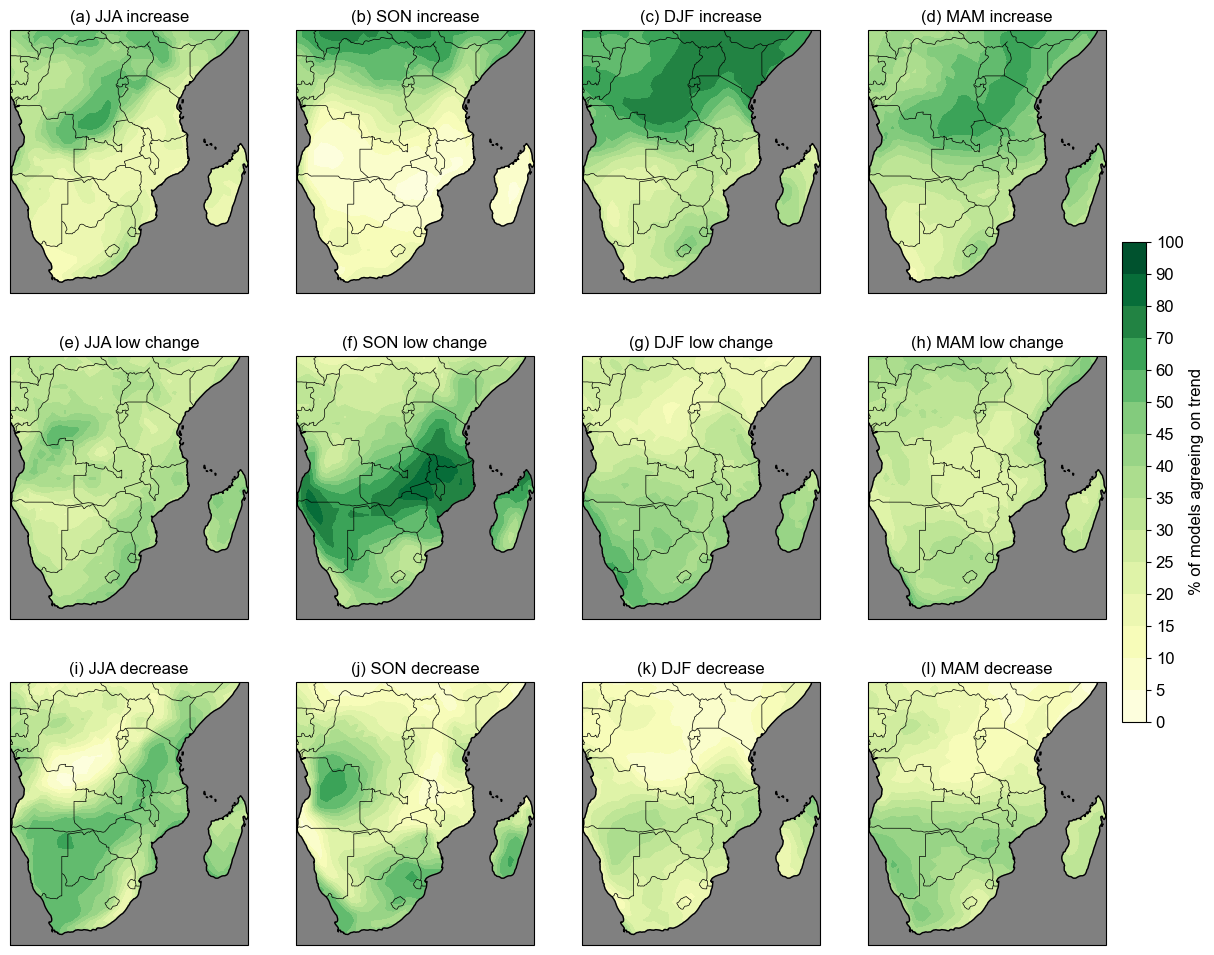

In [5]:
levels1 = np.concatenate((np.linspace(0,50,11),np.linspace(60,100,5)))
levels2 = np.linspace(-4, 4, 4)

fig, axs = plt.subplots(3, 4, figsize=(16,12), subplot_kw={'projection': ccrs.PlateCarree()})

## agree plots

c00 = axs[0,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[0,0].coastlines()
axs[0,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,0].set_title('(a) JJA increase',fontname = 'arial')

c01 = axs[0,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[0,1].coastlines()
axs[0,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,1].set_title('(b) SON increase',fontname = 'arial')

c0 = axs[0,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[0,2].coastlines()
axs[0,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,2].set_title('(c) DJF increase',fontname = 'arial')

c1 = axs[0,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[0,3].coastlines()
axs[0,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,3].set_title('(d) MAM increase',fontname = 'arial')

c00 = axs[1,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==0,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[1,0].coastlines()
axs[1,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,0].set_title('(e) JJA low change',fontname = 'arial')

c01 = axs[1,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==0,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[1,1].coastlines()
axs[1,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,1].set_title('(f) SON low change',fontname = 'arial')

c0 = axs[1,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==0,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[1,2].coastlines()
axs[1,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,2].set_title('(g) DJF low change',fontname = 'arial')


c1 = axs[1,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==0,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[1,3].coastlines()
axs[1,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,3].set_title('(h) MAM low change',fontname = 'arial')


c00 = axs[2,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==-1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[2,0].coastlines()
axs[2,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,0].set_title('(i) JJA decrease',fontname = 'arial')

c01 = axs[2,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==-1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[2,1].coastlines()
axs[2,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,1].set_title('(j) SON decrease',fontname = 'arial')

c0 = axs[2,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==-1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[2,2].coastlines()
axs[2,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,2].set_title('(k) DJF decrease',fontname = 'arial')


c1 = axs[2,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==-1,axis=3),axis=0))/(44*30)*100, cmap='YlGn',
                        levels=levels1,
                        transform=ccrs.PlateCarree())
axs[2,3].coastlines()
axs[2,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,3].set_title('(l) MAM decrease',fontname = 'arial')



fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.82, 0.3, 0.015, 0.4])
cbar = fig.colorbar(c1, cax=cbar_ax,label = '% of models',ticks=[0,5,10,15,20,25,30,35,40,45,50,60,70,80,90,100])
#cbar.ax.tick_params(labelsize=11)
cbar.set_label(label='% of models agreeing on trend',size=12)
# cbar.ax.set_yticklabels(['100 % drying','90 %','80 %','70 %','60 %','50 %','60 %', '70 %','80 %',' 90 %','100 % wetting'])  

cbar.ax.tick_params(labelsize=12)

plt.savefig('Figure8_trend_type2.pdf')

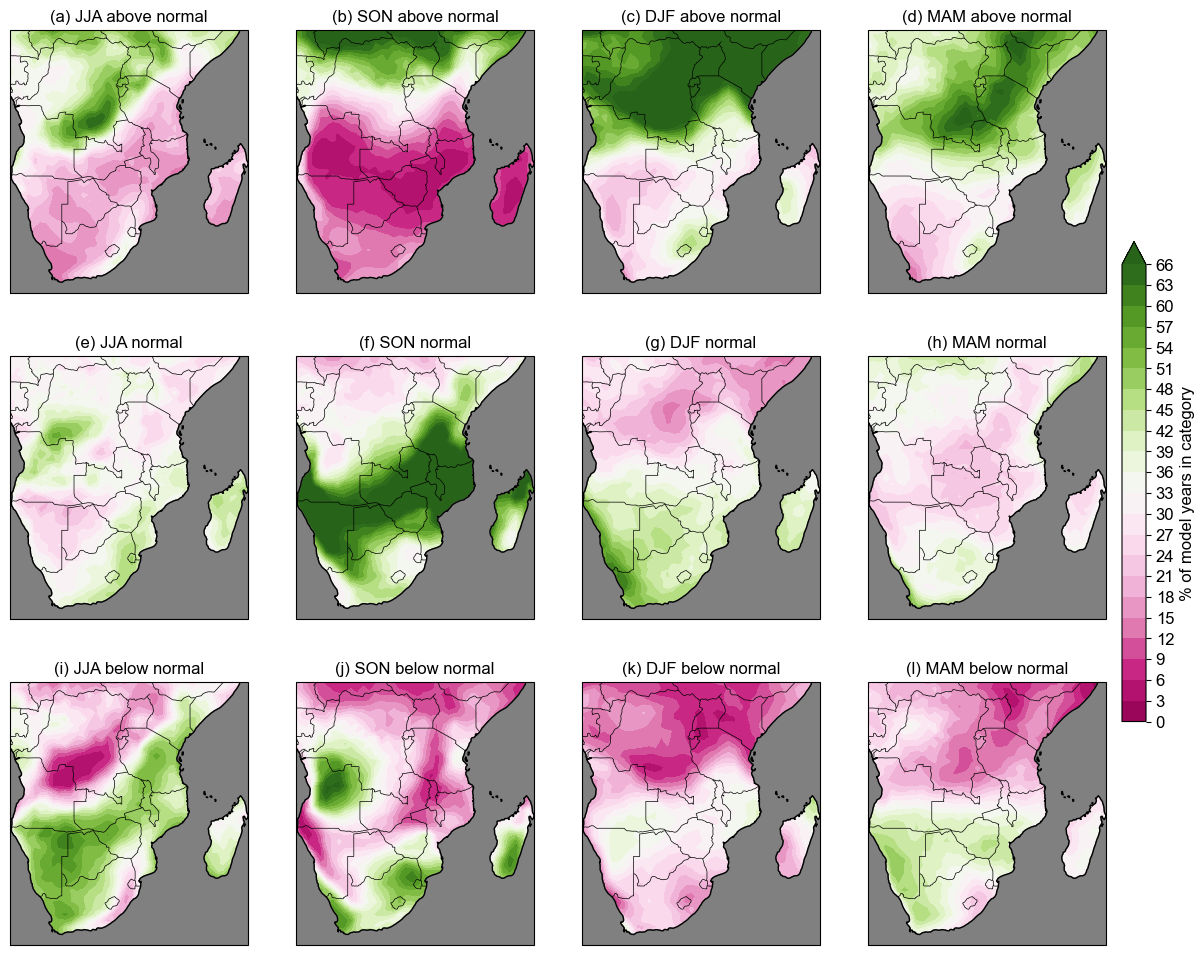

In [6]:
levels1 = np.concatenate((np.linspace(0,33,12),np.linspace(39,100,12)))
levels1 = np.linspace(0,66,23)
levels2 = np.linspace(-4, 4, 4)

fig, axs = plt.subplots(3, 4, figsize=(16,12), subplot_kw={'projection': ccrs.PlateCarree()})

## agree plots

c00 = axs[0,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[0,0].coastlines()
axs[0,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,0].set_title('(a) JJA above normal',fontname = 'arial')

c01 = axs[0,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[0,1].coastlines()
axs[0,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,1].set_title('(b) SON above normal',fontname = 'arial')

c0 = axs[0,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[0,2].coastlines()
axs[0,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,2].set_title('(c) DJF above normal',fontname = 'arial')

c1 = axs[0,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[0,3].coastlines()
axs[0,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[0,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[0,3].set_title('(d) MAM above normal',fontname = 'arial')

c00 = axs[1,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==0,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[1,0].coastlines()
axs[1,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,0].set_title('(e) JJA normal',fontname = 'arial')

c01 = axs[1,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==0,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[1,1].coastlines()
axs[1,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,1].set_title('(f) SON normal',fontname = 'arial')

c0 = axs[1,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==0,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[1,2].coastlines()
axs[1,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,2].set_title('(g) DJF normal',fontname = 'arial')


c1 = axs[1,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==0,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[1,3].coastlines()
axs[1,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[1,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[1,3].set_title('(h) MAM normal',fontname = 'arial')


c00 = axs[2,0].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsJJA==-1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[2,0].coastlines()
axs[2,0].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,0].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,0].set_title('(i) JJA below normal',fontname = 'arial')

c01 = axs[2,1].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsSON==-1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[2,1].coastlines()
axs[2,1].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,1].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,1].set_title('(j) SON below normal',fontname = 'arial')

c0 = axs[2,2].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsDJF==-1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[2,2].coastlines()
axs[2,2].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,2].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,2].set_title('(k) DJF below normal',fontname = 'arial')


c1 = axs[2,3].contourf(lons, lats, np.squeeze(np.sum(np.sum(TrendsMAM==-1,axis=3),axis=0))/(44*30)*100, cmap='PiYG',
                        levels=levels1,extend='max',
                        transform=ccrs.PlateCarree())
axs[2,3].coastlines()
axs[2,3].add_feature(cf.BORDERS, linewidth = 0.5)
axs[2,3].add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
axs[2,3].set_title('(l) MAM below normal',fontname = 'arial')



fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.82, 0.3, 0.015, 0.4])
cbar = fig.colorbar(c1, cax=cbar_ax,label = '% of models',ticks=levels1)
#cbar.ax.tick_params(labelsize=11)
cbar.set_label(label='% of model years in category',size=12)
# cbar.ax.set_yticklabels(['100 % drying','90 %','80 %','70 %','60 %','50 %','60 %', '70 %','80 %',' 90 %','100 % wetting'])  

cbar.ax.tick_params(labelsize=12)

plt.savefig('Figure8_trend_type2.pdf')

/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_5354/160590509.py:2: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = np.array(scipy.stats.mode(Trends,axis = 2));


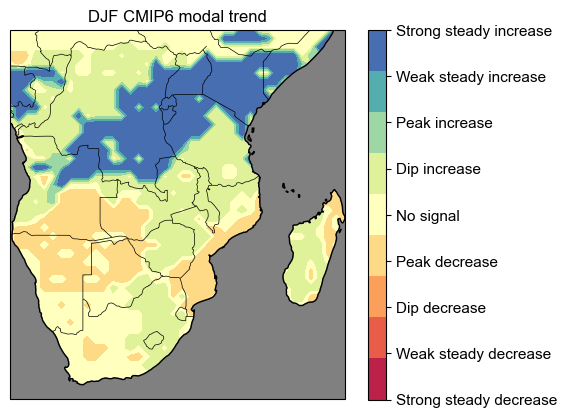

In [52]:
## Plot every model
mode = np.array(scipy.stats.mode(TrendsDJF,axis = 2));


levels = np.linspace(-4, 4, 10)


ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, mode[0,:,:,0], 60,levels=levels,
                 transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
plt.set_cmap("Spectral")
plt.title('DJF CMIP6 modal trend',fontname = 'arial')
cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('DJF CMIP6 mode.png')
#plt.show()

/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_5354/1586815725.py:2: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = np.array(scipy.stats.mode(TrendsSON,axis = 2));


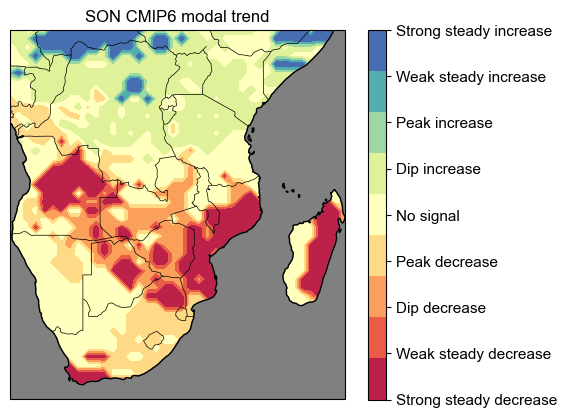

In [84]:
## Plot every model
mode = np.array(scipy.stats.mode(TrendsSON,axis = 2));


levels = np.linspace(-4, 4, 10)


ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, mode[0,:,:,0], 60,levels=levels,
                 transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
plt.set_cmap("Spectral")
plt.title('SON CMIP6 modal trend',fontname = 'arial')
cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('SON CMIP6 mode.png')
#plt.show()

/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_5354/216474622.py:2: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = np.array(scipy.stats.mode(TrendsSON,axis = 2));


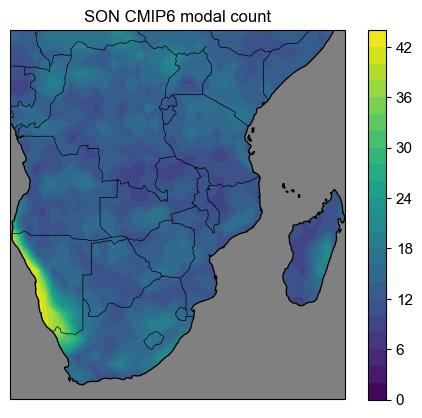

In [80]:
## Plot every model
mode = np.array(scipy.stats.mode(TrendsSON,axis = 2));


levels = np.linspace(0, 44, 23)


ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, mode[1,:,:,0], 60,levels=levels,
                 transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
plt.set_cmap("viridis")
plt.title('SON CMIP6 modal count',fontname = 'arial')
cbar = plt.colorbar(cax)#,ticks=[-4,-3,-2,-1,0,1,2,3,4])
#cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
#plt.savefig('SON CMIP6 mode.png')
plt.show()

In [20]:
## Plot every model

levels = np.linspace(-4, 4, 10)

for x in range(0,186):
    titlex = names[x]
    if x<94:
        titlex = titlex[6:-51]+" "+titlex[-27:-19]
    else:
        titlex = titlex[6:-45]+" "+titlex[-22:-16]

    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    cax = plt.contourf(lons, lats, Trends[:,:,x], 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("Spectral")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('DJF '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    # cbar = plt.colorbar(label="Precip. mm/day standard deviation")
    cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('DJF '+titlex+'.png')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
## Plot every model

levels = np.linspace(-4, 4, 10)

for x in range(0,186):
    titlex = names[x]
    if x<94:
        titlex = titlex[6:-51]+" "+titlex[-27:-19]
    else:
        titlex = titlex[6:-45]+" "+titlex[-22:-16]

    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    cax = plt.contourf(lons, lats, TrendsSON[:,:,x], 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("Spectral")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('SON '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    # cbar = plt.colorbar(label="Precip. mm/day standard deviation")
    cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('SON '+titlex+'.png')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [60]:
## Code for trend analysis for JJA

month_pattern = [5,6,7]#[0,1,11]

P1 = np.mean(P_all[month_pattern,:,:,:,0],axis=0)
P2 = np.mean(P_all[month_pattern,:,:,:,1],axis=0)
P3 = np.mean(P_all[month_pattern,:,:,:,2],axis=0)
P4 = np.mean(P_all[month_pattern,:,:,:,3],axis=0)

# Blank output array
TrendsJJA = np.empty(P1.shape)

# Check each grid cell and model
for i in range(0,44):
    for j in range(0,40):
        for k in range(0,186):
            # Steady large increase
            if P2[i,j,k] > 0 and P3[i,j,k] > P2[i,j,k] and P4[i,j,k] > P3[i,j,k]:
                if P4[i,j,k]>0.05:
                    TrendsJJA[i,j,k] = 4
                # Steady weak increase
                else:
                    TrendsJJA[i,j,k] = 3
    
            # Peak increase
            if P4[i,j,k] > 0 and (P4[i,j,k] < P2[i,j,k] or P4[i,j,k] < P3[i,j,k]):
                TrendsJJA[i,j,k] = 2
                
            # Dip increase
            if P4[i,j,k] > 0 and (P2[i,j,k] < 0 or P3[i,j,k] < 0):
                TrendsJJA[i,j,k] = 1
                
            # Steady large decrease
            if P2[i,j,k] < 0 and P3[i,j,k] < P2[i,j,k] and P4[i,j,k] < P3[i,j,k]:
                if P4[i,j,k]<-0.05:
                    TrendsJJA[i,j,k] = -4
                # Steady weak increase
                else:
                    TrendsJJA[i,j,k] = -3
    
            # Dip decrease
            if P4[i,j,k] < 0 and (P4[i,j,k] > P2[i,j,k] or P4[i,j,k] > P3[i,j,k]):
                TrendsJJA[i,j,k] = -2
                
            # Peak decrease
            if P4[i,j,k] < 0 and (P2[i,j,k] > 0 or P3[i,j,k] > 0):
                TrendsJJA[i,j,k] = -1
                
            # No strong trend
            if abs(P4[i,j,k])<0.01:
                TrendsJJA[i,j,k] = 0
            
            # Remove physically unrealistic values that exceed present day obs.
            if P4[i,j,k] < -obs_max_JJA[i,j]:
                TrendsJJA[i,j,k] = np.nan
            

In [61]:
## Code for trend analysis for SON

month_pattern = [8,9,10]#[5,6,7]#[0,1,11]

P1 = np.mean(P_all[month_pattern,:,:,:,0],axis=0)
P2 = np.mean(P_all[month_pattern,:,:,:,1],axis=0)
P3 = np.mean(P_all[month_pattern,:,:,:,2],axis=0)
P4 = np.mean(P_all[month_pattern,:,:,:,3],axis=0)

# Blank output array
TrendsSON = np.empty(P1.shape)

# Check each grid cell and model
for i in range(0,44):
    for j in range(0,40):
        for k in range(0,186):
            # Steady large increase
            if P2[i,j,k] > 0 and P3[i,j,k] > P2[i,j,k] and P4[i,j,k] > P3[i,j,k]:
                if P4[i,j,k]>0.5:
                    TrendsSON[i,j,k] = 4
                # Steady weak increase
                else:
                    TrendsSON[i,j,k] = 3
    
            # Peak increase
            if P4[i,j,k] > 0 and (P4[i,j,k] < P2[i,j,k] or P4[i,j,k] < P3[i,j,k]):
                TrendsSON[i,j,k] = 2
                
            # Dip increase
            if P4[i,j,k] > 0 and (P2[i,j,k] < 0 or P3[i,j,k] < 0):
                TrendsSON[i,j,k] = 1
                
            # Steady large decrease
            if P2[i,j,k] < 0 and P3[i,j,k] < P2[i,j,k] and P4[i,j,k] < P3[i,j,k]:
                if P4[i,j,k]<-0.5:
                    TrendsSON[i,j,k] = -4
                # Steady weak increase
                else:
                    TrendsSON[i,j,k] = -3
    
            # Dip decrease
            if P4[i,j,k] < 0 and (P4[i,j,k] > P2[i,j,k] or P4[i,j,k] > P3[i,j,k]):
                TrendsSON[i,j,k] = -2
                
            # Peak decrease
            if P4[i,j,k] < 0 and (P2[i,j,k] > 0 or P3[i,j,k] > 0):
                TrendsSON[i,j,k] = -1
                
            # No strong trend
            if abs(P4[i,j,k])<0.05:
                TrendsSON[i,j,k] = 0
            
            # Remove physically unrealistic values that exceed present day obs.
            if P4[i,j,k] < -obs_max_SON[i,j]:
                TrendsSON[i,j,k] = np.nan
            

In [24]:
## Plot every model

levels = np.linspace(-4, 4, 10)

for x in range(0,186):
    titlex = names[x]
    if x<94:
        titlex = titlex[6:-51]+" "+titlex[-27:-19]
    else:
        titlex = titlex[6:-45]+" "+titlex[-22:-16]

    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    cax = plt.contourf(lons, lats, TrendsJJA[:,:,x], 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("Spectral")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('JJA '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    # cbar = plt.colorbar(label="Precip. mm/day standard deviation")
    cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('JJA '+titlex+'.png')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [62]:
## Code for trend analysis for MAM

month_pattern = [2,3,4]#[5,6,7]#[0,1,11]

P1 = np.mean(P_all[month_pattern,:,:,:,0],axis=0)
P2 = np.mean(P_all[month_pattern,:,:,:,1],axis=0)
P3 = np.mean(P_all[month_pattern,:,:,:,2],axis=0)
P4 = np.mean(P_all[month_pattern,:,:,:,3],axis=0)

# Blank output array
TrendsMAM = np.empty(P1.shape)

# Check each grid cell and model
for i in range(0,44):
    for j in range(0,40):
        for k in range(0,186):
            # Steady large increase
            if P2[i,j,k] > 0 and P3[i,j,k] > P2[i,j,k] and P4[i,j,k] > P3[i,j,k]:
                if P4[i,j,k]>0.5:
                    TrendsMAM[i,j,k] = 4
                # Steady weak increase
                else:
                    TrendsMAM[i,j,k] = 3
    
            # Peak increase
            if P4[i,j,k] > 0 and (P4[i,j,k] < P2[i,j,k] or P4[i,j,k] < P3[i,j,k]):
                TrendsMAM[i,j,k] = 2
                
            # Dip increase
            if P4[i,j,k] > 0 and (P2[i,j,k] < 0 or P3[i,j,k] < 0):
                TrendsMAM[i,j,k] = 1
                
            # Steady large decrease
            if P2[i,j,k] < 0 and P3[i,j,k] < P2[i,j,k] and P4[i,j,k] < P3[i,j,k]:
                if P4[i,j,k]<-0.5:
                    TrendsMAM[i,j,k] = -4
                # Steady weak increase
                else:
                    TrendsMAM[i,j,k] = -3
    
            # Dip decrease
            if P4[i,j,k] < 0 and (P4[i,j,k] > P2[i,j,k] or P4[i,j,k] > P3[i,j,k]):
                TrendsMAM[i,j,k] = -2
                
            # Peak decrease
            if P4[i,j,k] < 0 and (P2[i,j,k] > 0 or P3[i,j,k] > 0):
                TrendsMAM[i,j,k] = -1
                
            # No strong trend
            if abs(P4[i,j,k])<0.05:
                TrendsMAM[i,j,k] = 0
            
            # Remove physically unrealistic values that exceed present day obs.
            if P4[i,j,k] < -obs_max_MAM[i,j]:
                TrendsMAM[i,j,k] = np.nan
            

In [26]:
## Plot every model

levels = np.linspace(-4, 4, 10)

for x in range(0,186):
    titlex = names[x]
    if x<94:
        titlex = titlex[6:-51]+" "+titlex[-27:-19]
    else:
        titlex = titlex[6:-45]+" "+titlex[-22:-16]

    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    cax = plt.contourf(lons, lats, TrendsMAM[:,:,x], 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("Spectral")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('MAM '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    # cbar = plt.colorbar(label="Precip. mm/day standard deviation")
    cbar = plt.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('MAM '+titlex+'.png')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [63]:
plottitles = ['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase']
levels = np.linspace(0, 100, 11)

for x in range(0,9):
    vals2plot = np.sum(Trends[:,:,:]==x-4,axis=2)/1.86
    titlex = plottitles[x]
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("YlOrBr")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('DJF '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    cbar = plt.colorbar(label="% of models agreeing on signal")
    #cbar = fig.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    #cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('DJF '+titlex+'.pdf')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [64]:
plottitles = ['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase']
levels = np.linspace(0, 100, 11)

for x in range(0,9):
    vals2plot = np.sum(TrendsSON[:,:,:]==x-4,axis=2)/1.86
    titlex = plottitles[x]
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("YlOrBr")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('SON '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    cbar = plt.colorbar(label="% of models agreeing on signal")
    #cbar = fig.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    #cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('SON '+titlex+'.pdf')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [65]:
plottitles = ['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase']
levels = np.linspace(0, 100, 11)

for x in range(0,9):
    vals2plot = np.sum(TrendsMAM[:,:,:]==x-4,axis=2)/1.86
    titlex = plottitles[x]
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("YlOrBr")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('MAM '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    cbar = plt.colorbar(label="% of models agreeing on signal")
    #cbar = fig.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    #cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('MAM '+titlex+'.pdf')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

In [66]:
plottitles = ['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase']
levels = np.linspace(0, 100, 11)

for x in range(0,9):
    vals2plot = np.sum(TrendsJJA[:,:,:]==x-4,axis=2)/1.86
    titlex = plottitles[x]
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
                 transform=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cf.BORDERS, linewidth = 0.5)
    ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)
    
    plt.set_cmap("YlOrBr")
    
    #bounds = [-1, 0, 1, 2, 3, 4]
    #norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N, extend='both')
    
    plt.title('JJA '+titlex,fontname = 'arial')
    #plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label="Temperature anomaly from 1951-1980 (°C)")
    cbar = plt.colorbar(label="% of models agreeing on signal")
    #cbar = fig.colorbar(cax,ticks=[-4,-3,-2,-1,0,1,2,3,4])
    #cbar.ax.set_yticklabels(['Strong steady decrease', 'Weak steady decrease', 'Dip decrease','Peak decrease','No signal','Dip increase','Peak increase','Weak steady increase','Strong steady increase'])  # horizontal colorbar
    
    cbar.ax.tick_params(labelsize=11)
    plt.gcf().subplots_adjust(right=0.8,left=0.1)
    plt.savefig('JJA '+titlex+'.pdf')
    plt.clf()
    #plt.show()

<Figure size 640x480 with 0 Axes>

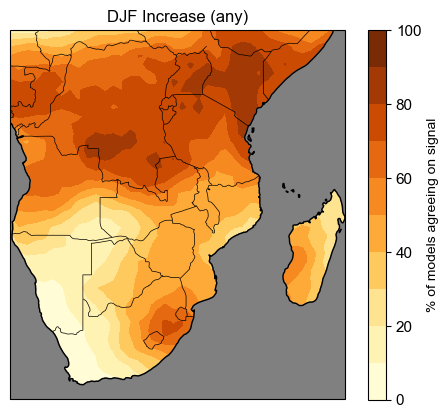

In [28]:
levels = np.linspace(0, 100, 11)

vals2plot = np.sum(np.isnan(TrendsJJA[:,:,:]),axis=2)/1.86
titlex = "Unrealistic (decrease exceeds obs. baseline)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('JJA '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('JJA '+titlex+'.png')
plt.clf()

vals2plot = np.sum(Trends[:,:,:]<0,axis=2)/1.86
titlex = "Decrease (any)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('DJF '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('DJF '+titlex+'.png')
plt.clf()

vals2plot = np.sum(Trends[:,:,:]>0,axis=2)/1.86
titlex = "Increase (any)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('DJF '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('DJF '+titlex+'.png')


In [29]:
levels = np.linspace(0, 100, 11)

vals2plot = np.sum(np.isnan(TrendsJJA[:,:,:]),axis=2)/1.86
titlex = "Unrealistic (decrease exceeds obs. baseline)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('JJA '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('JJA '+titlex+'.png')
plt.clf()


vals2plot = np.sum(np.isnan(TrendsSON[:,:,:]),axis=2)/1.86
titlex = "Unrealistic (decrease exceeds obs. baseline)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('SON '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('SON '+titlex+'.png')
plt.clf()


vals2plot = np.sum(np.isnan(TrendsMAM[:,:,:]),axis=2)/1.86
titlex = "Unrealistic (decrease exceeds obs. baseline)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('MAM '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('MAM '+titlex+'.png')
plt.clf()


vals2plot = np.sum(np.isnan(Trends[:,:,:]),axis=2)/1.86
titlex = "Unrealistic (decrease exceeds obs. baseline)"

ax = plt.axes(projection=ccrs.PlateCarree())
cax = plt.contourf(lons, lats, vals2plot, 60,levels=levels,
             transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth = 0.5)
ax.add_feature(cf.OCEAN, edgecolor='face', facecolor='grey', zorder=1)

plt.set_cmap("YlOrBr")

plt.title('DJF '+titlex,fontname = 'arial')
cbar = plt.colorbar(label="% of models agreeing on signal")
cbar.ax.tick_params(labelsize=11)
plt.gcf().subplots_adjust(right=0.8,left=0.1)
plt.savefig('DJF '+titlex+'.png')
plt.clf()


<Figure size 640x480 with 0 Axes>